# Fase 3 - Balanceamento dos Dados

Este arquivo implementa o balanceamento das classes da variável-alvo para evitar que o modelo de aprendizado de máquina se torne enviesado para a classe majoritária. Para isso, pode-se utilizar o **SMOTE (Synthetic Minority Over-sampling Technique)** ou o **ADASYN (Adaptive Synthetic Sampling)**, técnicas que criam amostras sintéticas da classe minoritária, equilibrando assim a distribuição das classes no conjunto de dados.

## **Etapas do Balanceamento dos Dados**
### **1. Carregamento dos Dados**
O conjunto de dados de treino é carregado a partir do arquivo salvo na fase anterior, possibilitando a continuação do fluxo de preparação.

### **2. Aplicação do SMOTE ou ADASYN para Balanceamento das Classes**
Tanto o SMOTE quanto o ADASYN podem ser utilizados para gerar amostras sintéticas da classe minoritária no conjunto de treino. Essas técnicas ajudam a balancear as classes, evitando que o modelo aprenda de forma enviesada para a classe mais frequente. A escolha entre SMOTE ou ADASYN pode depender das características específicas do problema, sendo o SMOTE mais generalista e o ADASYN mais adaptativo ao foco em amostras de fronteira.

### **3. Verificação das Proporções das Classes**
Após a aplicação do SMOTE ou ADASYN, são exibidas as novas proporções das classes no conjunto de dados de treino para confirmar o balanceamento adequado.

### **4. Salvamento dos Dados Balanceados**
Por fim, os dados balanceados são salvos em um arquivo para serem utilizados na próxima fase de treinamento e teste dos modelos.

### Balancear dados sem normalização

In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregar os dados de treino e teste
X_train, X_test, y_train, y_test = joblib.load('data/data_splits.pkl')

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Exibir as novas proporções
print("Proporções após SMOTE:")
print(y_resampled.value_counts(normalize=True))

# Salvar os dados reamostrados
joblib.dump((X_resampled, y_resampled), 'data/data_resampled.pkl')

FileNotFoundError: [Errno 2] No such file or directory: 'data/data_splits.pkl'

### Balancear dados com normalização

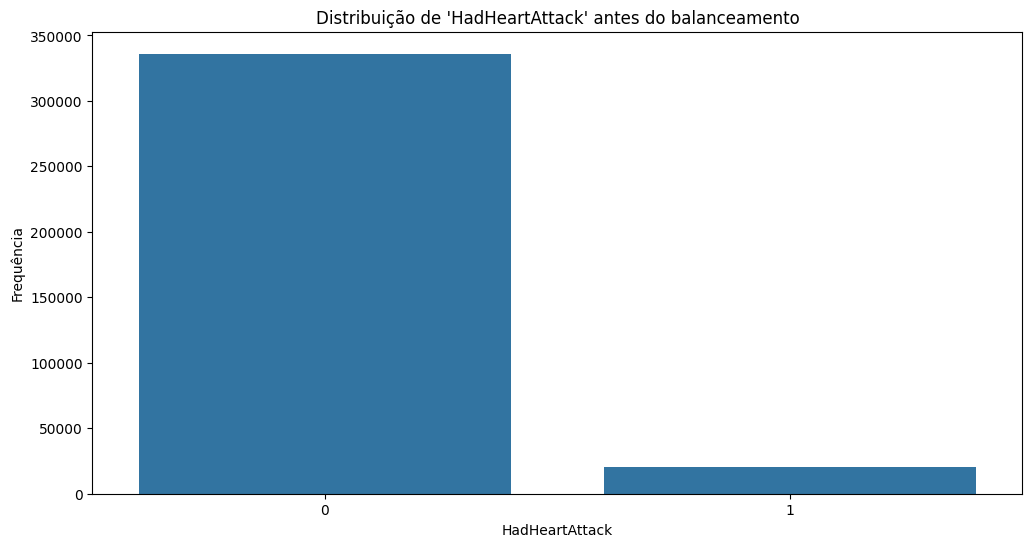

Proporções antes do SMOTE:
HadHeartAttack
0    0.943595
1    0.056405
Name: proportion, dtype: float64

Proporções após SMOTE:
HadHeartAttack
0    0.5
1    0.5
Name: proportion, dtype: float64


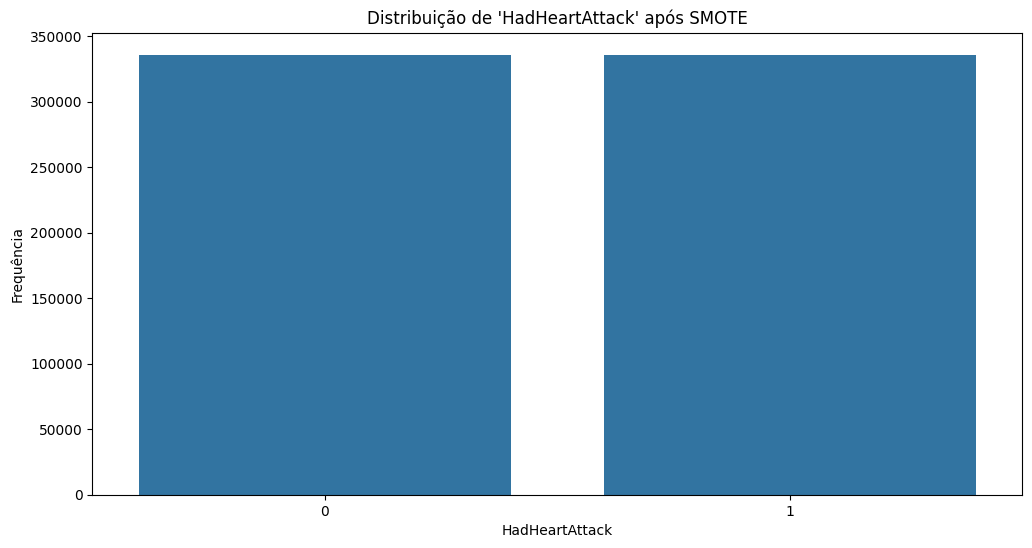

['data/data_resampled_normalized.pkl']

In [4]:
# Carregar os dados de treino e teste
X_train_scaled, X_test_scaled, y_train, y_test = joblib.load('data/data_splits_normalized.pkl')

# Visualização antes do balanceamento
plt.figure(figsize=(12, 6))
sns.countplot(x=y_train)
plt.title("Distribuição de 'HadHeartAttack' antes do balanceamento")
plt.xlabel("HadHeartAttack")
plt.ylabel("Frequência")
plt.show()

# Exibir as proporções antes do SMOTE
print("Proporções antes do SMOTE:")
print(y_train.value_counts(normalize=True))

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

# Exibir as proporções após o SMOTE
print("\nProporções após SMOTE:")
print(y_resampled.value_counts(normalize=True))

# Visualização após SMOTE
plt.figure(figsize=(12, 6))
sns.countplot(x=y_resampled)
plt.title("Distribuição de 'HadHeartAttack' após SMOTE")
plt.xlabel("HadHeartAttack")
plt.ylabel("Frequência")
plt.show()

# Salvar os dados reamostrados
joblib.dump((X_resampled, y_resampled), 'data/data_resampled_normalized.pkl')

Proporções antes do ADASYN:
HadHeartAttack
0    0.943595
1    0.056405
Name: proportion, dtype: float64

Proporções após ADASYN:
HadHeartAttack
0    0.500201
1    0.499799
Name: proportion, dtype: float64


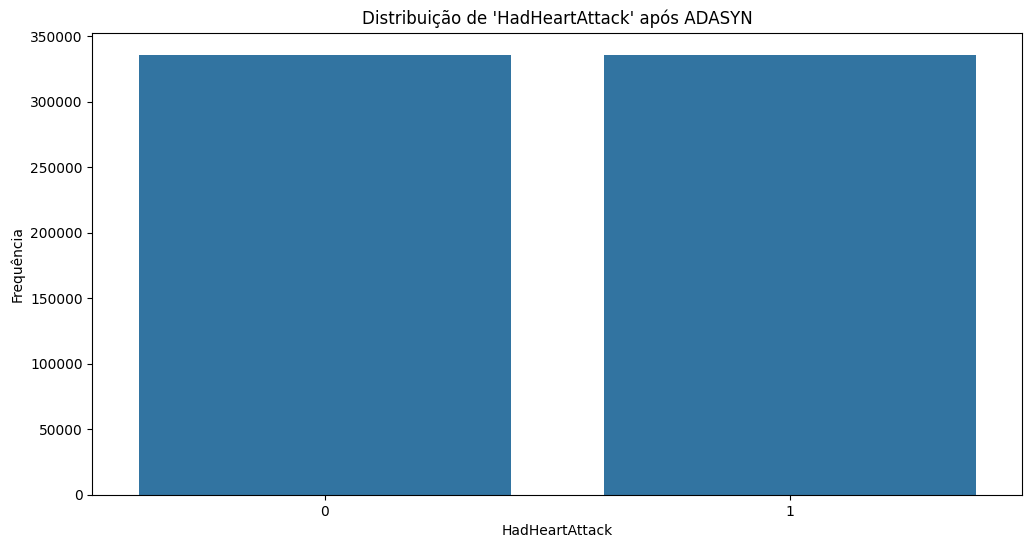

['data/data_resampled_normalized_async.pkl']

In [10]:
import joblib
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier

# Carregar os dados de treino e teste
X_train_scaled, X_test_scaled, y_train, y_test = joblib.load('data/data_splits_normalized.pkl')

# Exibir as proporções antes do ADASYN
print("Proporções antes do ADASYN:")
print(y_train.value_counts(normalize=True))

# Aplicar ADASYN
adasyn = ADASYN(random_state=42, sampling_strategy='minority')
X_resampled_adasyn, y_resampled_adasyn = adasyn.fit_resample(X_train_scaled, y_train)

# Exibir as proporções após o ADASYN
print("\nProporções após ADASYN:")
print(y_resampled_adasyn.value_counts(normalize=True))
# Visualização após ADASYN
plt.figure(figsize=(12, 6))
sns.countplot(x=y_resampled_adasyn)
plt.title("Distribuição de 'HadHeartAttack' após ADASYN")
plt.xlabel("HadHeartAttack")
plt.ylabel("Frequência")
plt.show()

# Salvar os dados reamostrados
joblib.dump((X_resampled_adasyn, y_resampled_adasyn), 'data/data_resampled_normalized_async.pkl')

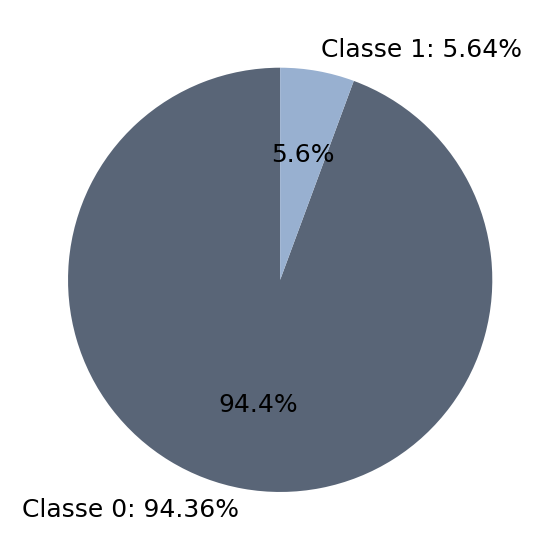

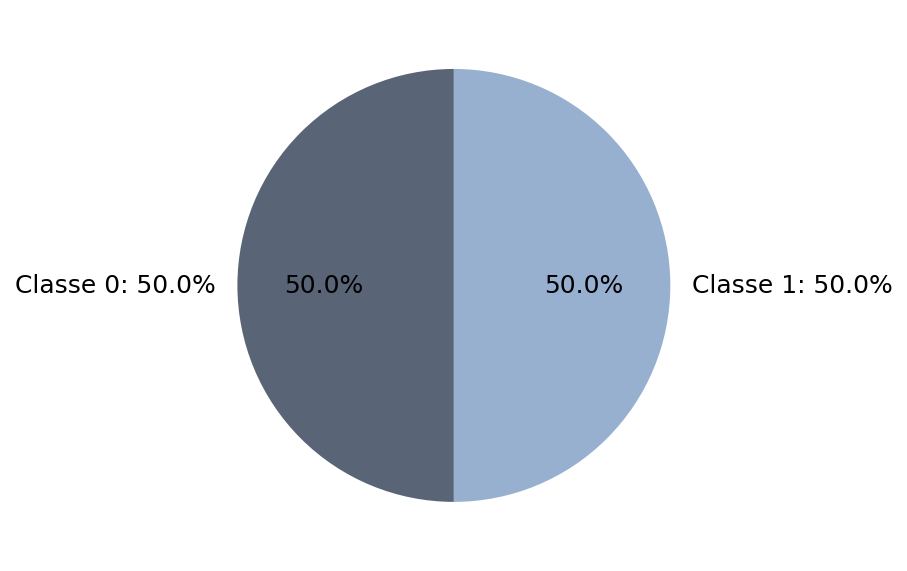

In [21]:
import matplotlib.pyplot as plt
import joblib
from imblearn.over_sampling import SMOTE

# Carregar os dados de treino e teste
X_train_scaled, X_test_scaled, y_train, y_test = joblib.load('data/data_splits_normalized.pkl')

# Função para calcular e plotar o gráfico de pizza com porcentagens
def plot_pie_chart(ax, y):
    percentage = y.value_counts(normalize=True) * 100
    # Cores: azul escuro e azul claro
    colors = ['#596577', '#98b0d0']  
    
    labels = [f"Classe {int(label)}: {round(val, 2)}%" for label, val in zip(percentage.index, percentage.values)]
    ax.pie(percentage, labels=labels,
           autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 12})

# Criar a figura e o gráfico para antes do balanceamento
fig, ax = plt.subplots(figsize=(4, 4), dpi=150)  
plot_pie_chart(ax, y_train)
plt.tight_layout()  
fig.savefig("distribuicao_antes_balanceamento.png", dpi=150)  

# Criar a figura e o gráfico para após o balanceamento
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)  
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)
plot_pie_chart(ax, y_resampled)
plt.tight_layout() 
fig.savefig("distribuicao_apos_smote.png", dpi=150)  
plt.show()